# Step 3 Part B: Rebalancing + P&L tracking loop

Building on the BS delta from Part A. Now we simulate actually holding a hedge position: rebalance to the new delta each hour, pay transaction costs on what we trade, and track cumulative P&L across the episode (one option, one sampled day).

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

train = pd.read_csv("btc_options_train.csv")
train["hour_bucket"] = pd.to_datetime(train["hour_bucket"])
train["sample_date"] = train["hour_bucket"].dt.date

def bs_delta(S, K, T_years, sigma, option_type, r=0.0):
    if T_years <= 0 or sigma <= 0:
        if option_type == "call":
            return 1.0 if S > K else 0.0
        else:
            return -1.0 if S < K else 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T_years) / (sigma * np.sqrt(T_years))
    return norm.cdf(d1) if option_type == "call" else norm.cdf(d1) - 1.0

counts = train.groupby(["symbol", "sample_date"]).size().sort_values(ascending=False)
proto_symbol, proto_date = counts.index[0]
episode = train[(train["symbol"] == proto_symbol) & (train["sample_date"] == proto_date)].sort_values("hour_bucket").reset_index(drop=True)
episode["T_years"] = episode["time_to_maturity_days"] / 365
episode["iv_decimal"] = episode["mark_iv"] / 100
episode["bs_delta"] = episode.apply(
    lambda row: bs_delta(row["underlying_price"], row["strike_price"], row["T_years"], row["iv_decimal"], row["type"]), axis=1
)
print(f"Episode: {proto_symbol} on {proto_date}, {len(episode)} hourly steps")
episode[["hour_bucket", "underlying_price", "bs_delta", "bid_price", "ask_price"]].head()

Episode: BTC-10APR20-5000-P on 2020-04-01, 24 hourly steps


,hour_bucket,underlying_price,bs_delta,bid_price,ask_price
0,2020-04-01 00:00:00,6311.30,-0.101396,0.0095,0.0110
1,2020-04-01 01:00:00,6288.30,-0.102219,0.0095,0.0110
2,2020-04-01 02:00:00,6319.42,-0.097306,0.0090,0.0105
3,2020-04-01 03:00:00,6372.24,-0.092845,0.0085,0.0100
4,2020-04-01 04:00:00,6344.92,-0.093918,0.0085,0.0100


## The simulation loop

At each hourly step:
1. Compute the target hedge position (= BS delta) for this step
2. Compute how much BTC we need to buy/sell to move from our current position to the target
3. Pay a transaction cost on that trade -- we approximate cost using half the relative bid-ask spread of the OPTION as a proxy for hedging friction (a simplification; in a full study you'd also model the spot/perp market's own spread, but this keeps things tractable for now and is a defensible simplification to state explicitly in the paper)
4. Track cumulative cost and the running P&L of the combined position (option + hedge)


In [2]:
def simulate_hedge(episode_df, target_delta_col="bs_delta", cost_rate_col="relative_spread"):
    """
    Simulate hedging one option across its episode.
    Returns a dataframe with position, trades, costs, and P&L per step.
    """
    n = len(episode_df)
    position = np.zeros(n)       # BTC hedge position held AFTER rebalancing at each step
    trade_size = np.zeros(n)     # BTC bought(+)/sold(-) at each step
    transaction_cost = np.zeros(n)  # cost paid at each step (in USD)
    hedge_pnl = np.zeros(n)      # P&L of the hedge position from price moves

    current_position = 0.0
    for i in range(n):
        target = episode_df[target_delta_col].iloc[i]
        trade = target - current_position
        trade_size[i] = trade

        spot = episode_df["underlying_price"].iloc[i]
        cost_rate = episode_df[cost_rate_col].iloc[i]  # relative spread, e.g. 0.03 = 3%
        # cost = half-spread * notional traded (standard approximation: you cross half the spread per trade)
        transaction_cost[i] = abs(trade) * spot * (cost_rate / 2)

        if i > 0:
            prev_spot = episode_df["underlying_price"].iloc[i - 1]
            hedge_pnl[i] = current_position * (spot - prev_spot)  # P&L on the position held BEFORE this rebalance

        current_position = target
        position[i] = current_position

    result = episode_df.copy()
    result["position"] = position
    result["trade_size"] = trade_size
    result["transaction_cost"] = transaction_cost
    result["hedge_pnl"] = hedge_pnl
    result["cumulative_cost"] = transaction_cost.cumsum()
    result["cumulative_hedge_pnl"] = hedge_pnl.cumsum()
    return result

sim = simulate_hedge(episode)
sim[["hour_bucket", "underlying_price", "bs_delta", "position", "trade_size", "transaction_cost", "hedge_pnl", "cumulative_cost"]]

,hour_bucket,underlying_price,bs_delta,position,trade_size,transaction_cost,hedge_pnl,cumulative_cost
0,2020-04-01 00:00:00,6311.30,-0.101396,-0.101396,-0.101396,46.824912,0.000000,46.824912
1,2020-04-01 01:00:00,6288.30,-0.102219,-0.102219,-0.000823,0.378816,2.332108,47.203728
2,2020-04-01 02:00:00,6319.42,-0.097306,-0.097306,0.004913,2.388475,-3.181064,49.592203
3,2020-04-01 03:00:00,6372.24,-0.092845,-0.092845,0.004461,2.304756,-5.139694,51.896960
4,2020-04-01 04:00:00,6344.92,-0.093918,-0.093918,-0.001073,0.551781,2.536526,52.448741
5,2020-04-01 05:00:00,6307.90,-0.097181,-0.097181,-0.003263,2.166733,3.476829,54.615474
6,2020-04-01 06:00:00,6302.08,-0.098715,-0.098715,-0.001534,0.743748,0.565592,55.359222
7,2020-04-01 07:00:00,6333.76,-0.092211,-0.092211,0.006504,3.530891,-3.127291,58.890113
8,2020-04-01 08:00:00,6312.98,-0.094187,-0.094187,-0.001975,0.692834,1.916148,59.582947
9,2020-04-01 09:00:00,6302.53,-0.096189,-0.096189,-0.002003,0.341137,0.984250,59.924085


## Sanity check: plot position, cumulative cost, and cumulative hedge P&L

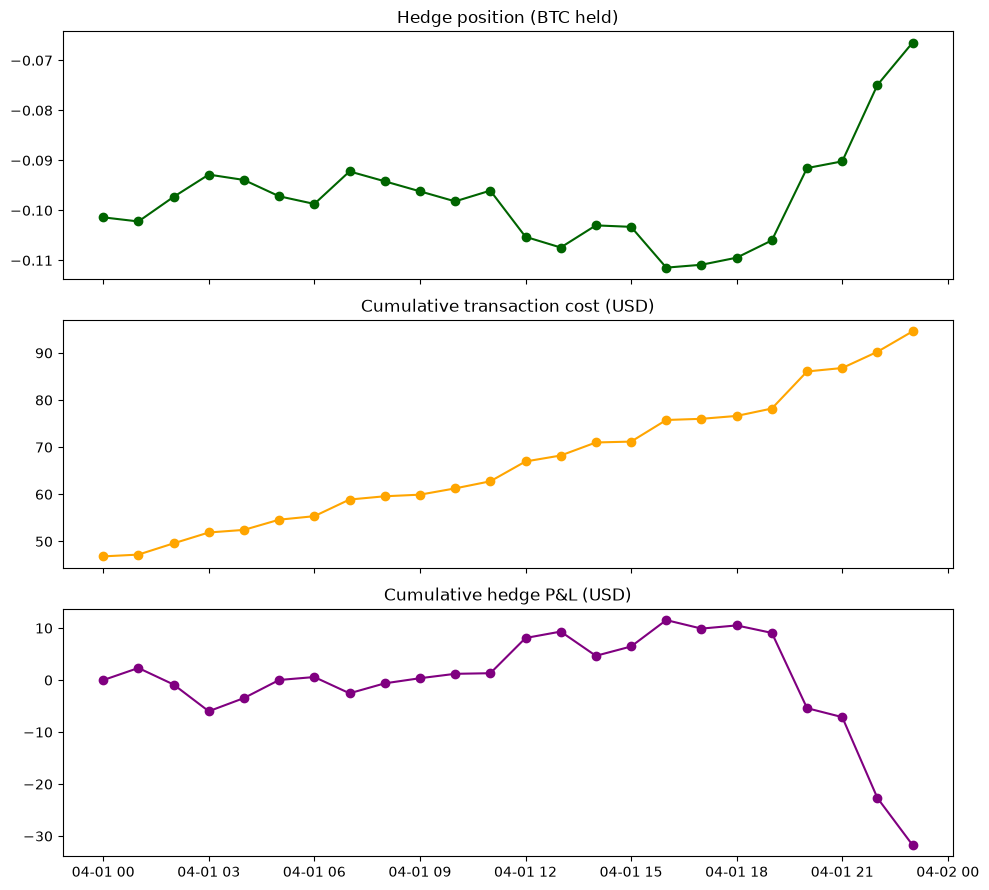

Total transaction cost over episode: $94.5924
Total hedge P&L over episode: $-31.7397
Total turnover (sum of |trades|): 0.201379 BTC


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
axes[0].plot(sim["hour_bucket"], sim["position"], marker="o", color="darkgreen")
axes[0].set_title("Hedge position (BTC held)")

axes[1].plot(sim["hour_bucket"], sim["cumulative_cost"], marker="o", color="orange")
axes[1].set_title("Cumulative transaction cost (USD)")

axes[2].plot(sim["hour_bucket"], sim["cumulative_hedge_pnl"], marker="o", color="purple")
axes[2].set_title("Cumulative hedge P&L (USD)")

plt.tight_layout()
plt.show()

print(f"Total transaction cost over episode: ${sim['transaction_cost'].sum():.4f}")
print(f"Total hedge P&L over episode: ${sim['hedge_pnl'].sum():.4f}")
print(f"Total turnover (sum of |trades|): {sim['trade_size'].abs().sum():.6f} BTC")